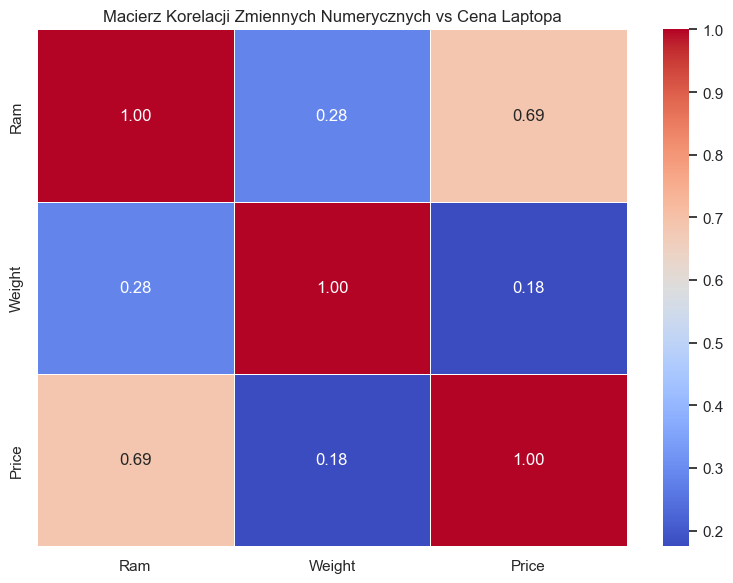

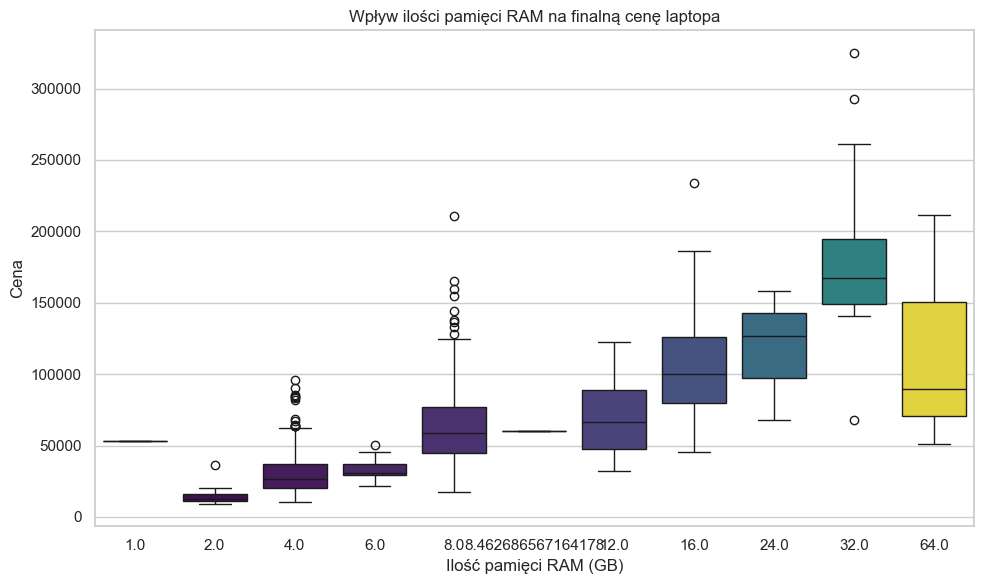

Próbka z przetworzonej w pełni macierzy:


,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
0,1,4,7,23,65,8.0,4,58,8,1.37
1,1,4,7,1,63,8.0,2,51,8,1.34
2,7,3,14,8,74,8.0,16,53,4,1.86
3,1,4,13,25,85,16.0,29,9,8,1.83
4,1,4,7,23,67,8.0,16,59,8,1.37


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder


# Wczytujemy dane z plik csv i od razu pozbywamy się ewentualnych śmieci
df = pd.read_csv('laptopy.csv')

 
# Usuwamy niepotrzebna kolumna z indeksem ('Unnamed: 0') dla zachowania przejrzystości.
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)


# Czyszczenie danych (data cleaning).
# Kolumny 'Ram' i 'Weight' są wczytywane jako typ tekstowy, 
# ponieważ zawierają jednostki miar ("GB" oraz "kg"), a czasami braki lub błędne znaki (np. "?").

# Kolumna 'Ram' usuwamy tekst "GB" i od razu wymuszamy konwersję do typu zmiennoprzecinkowego.
df['Ram'] = df['Ram'].str.replace('GB', '', regex=False)
df['Ram'] = pd.to_numeric(df['Ram'], errors='coerce')

# Kolumna 'Weight' usuwamy tekst "kg". 
# Każda wartość, której nie da się przerobić na liczbę (np. "?"), zostanie automatycznie zamieniona na brakujące dane (NaN).
df['Weight'] = df['Weight'].str.replace('kg', '', regex=False)
df['Weight'] = pd.to_numeric(df['Weight'], errors='coerce')


# Uzupełnianie brakujących danych (KNN imputer)

# Automatycznie filtrujemy z ramki wyłącznie kolumny numeryczne.
num_cols = df.select_dtypes(include=[np.number]).columns

# Inicjalizujemy KNNImputer
# 5 najbliższych sąsiadów to optymalny punkt wyjścia.
imputer = KNNImputer(n_neighbors=5, weights='distance')

# Uzupełniamy nasze kolumny (np. ewentualne wartości NaN w kolumnie 'Weight')
df[num_cols] = imputer.fit_transform(df[num_cols])

# Wizualizacja danych
sns.set_theme(style="whitegrid")

# Wykres_1 - macierz korelacji (Heatmap)
plt.figure(figsize=(8, 6))
# Liczymy korelację tylko pośród naszych imputowanych cech numerycznych
corr_matrix = df[num_cols].corr()

# Używamy przejrzystej mapy kolorów 'coolwarm' dla łatwego wyłapania siły związków w raporcie
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Macierz Korelacji Zmiennych Numerycznych vs Cena Laptopa")
plt.tight_layout()
plt.show()

# Wykres_2 - rozkład cen w zależności od ilości pamięci RAM (Boxplot)
plt.figure(figsize=(10, 6))
# Boxplot wskaże nie tylko trend wzrostowy, ale także wartości odstające (outliers)
sns.boxplot(data=df, x='Ram', y='Price', hue='Ram', palette='viridis', legend=False)
plt.title("Wpływ ilości pamięci RAM na finalną cenę laptopa")
plt.xlabel("Ilość pamięci RAM (GB)")
plt.ylabel("Cena")
plt.tight_layout()
plt.show()

# Przygotowanie zmiennych kategorycznych pod model ML.
# Aby algorytm ML zrozumiał zmienne takie jak nazwa firmy czy procesor, 
# przeprowadzamy ich transformację korzystając z automatycznej pętli z klasą LabelEncoder.

cat_cols = df.select_dtypes(include=['object']).columns

# Przetrzymujemy obiekty encodera w słowniku, 
# gdybyś w przyszłości (produkcyjnie) musiał odkodować zmienne (inverse_transform).
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    # Rzutujemy na ciąg tekstowy (.astype(str)), żeby ustrzec się błędu dla ukrytych typów
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# Tworzenie "Feature Matrix" (X) oraz targetu, który chcemy przewidzieć (y)
X = df.drop(columns=['Price'])
y = df['Price']

print("Próbka z przetworzonej w pełni macierzy:")
display(X.head())